### Zadanie 10

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates

In [40]:
np.random.seed(42)
dates = pd.date_range('2025-01-01', periods=100)
price = 100 + np.cumsum(np.random.randn(100))
df = pd.DataFrame({'date': dates, 'price': price})
df = df.set_index('date')
df['7d rolling avg'] = df['price'].rolling(7).mean()
df['21d rolling avg'] = df['price'].rolling(21).mean()
df

,price,7d rolling avg,21d rolling avg
date,,,
2025-01-01,100.496714,NaN,NaN
2025-01-02,100.358450,NaN,NaN
2025-01-03,101.006138,NaN,NaN
2025-01-04,102.529168,NaN,NaN
2025-01-05,102.295015,NaN,NaN
...,...,...,...
2025-04-06,89.287646,91.019657,91.026787
2025-04-07,89.583767,90.802014,90.902178
2025-04-08,89.844822,90.607797,90.785855


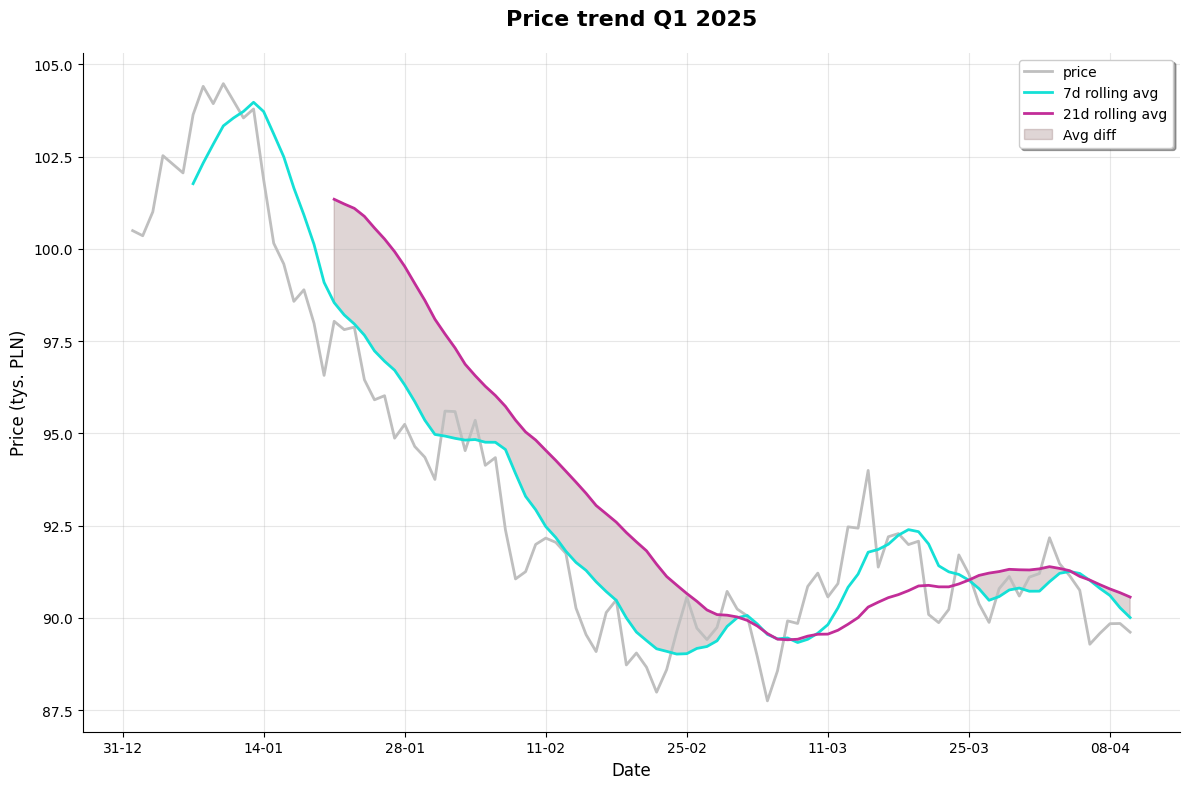

In [43]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(df.index,
        df['price'],
        color='#BFBFBF',
        linewidth=2,
        label='price')

ax.plot(df.index,
        df['7d rolling avg'],
        color='#14E0D6',
        linewidth=2,
        label='7d rolling avg')

ax.plot(df.index,
        df['21d rolling avg'],
        color='#C22D98',
        linewidth=2,
        label='21d rolling avg')

ax.fill_between(df.index,
                df['7d rolling avg'],
                df['21d rolling avg'],
                alpha=0.2,
                color='#612F2F',
                where=(df['21d rolling avg'] > df['7d rolling avg']),
                label='Avg diff')

ax.set_title('Price trend Q1 2025', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price (tys. PLN)', fontsize=12)

ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.grid(True, which='minor', linestyle=':', alpha=0.2)

ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))

plt.tight_layout()
plt.show()